# Ensemble Methods: Random Forest, AdaBoost & XGBoost
**Dataset:** Metro Interstate Traffic Volume  
**Objective:** Predict hourly traffic volume on I-94 using weather and temporal features, and compare **Random Forest**, **AdaBoost**, and **XGBoost** regressors.

## 1. Imports & Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('Metro_Interstate_Traffic_Volume.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (48204, 9)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


In [4]:
df.describe()

,temp,rain_1h,snow_1h,clouds_all,traffic_volume
count,48204.000000,48204.000000,48204.000000,48204.000000,48204.000000
mean,281.205870,0.334264,0.000222,49.362231,3259.818355
std,13.338232,44.789133,0.008168,39.015750,1986.860670
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,272.160000,0.000000,0.000000,1.000000,1193.000000
50%,282.450000,0.000000,0.000000,64.000000,3380.000000
75%,291.806000,0.000000,0.000000,90.000000,4933.000000
max,310.070000,9831.300000,0.510000,100.000000,7280.000000


In [5]:
# Missing values
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64

Duplicate rows: 17


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution

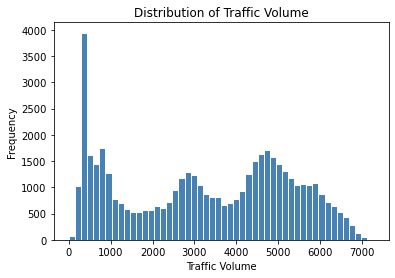

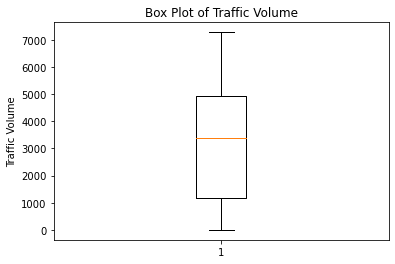

In [6]:
plt.hist(df['traffic_volume'], bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Traffic Volume')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')

plt.show()

plt.boxplot(df['traffic_volume'], vert=True)
plt.title('Box Plot of Traffic Volume')
plt.ylabel('Traffic Volume')

plt.show()

### 3.2 Temporal Feature Engineering & Analysis

In [7]:
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek  # Mon=0, Sun=6
df['month'] = df['date_time'].dt.month
df['year'] = df['date_time'].dt.year
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

print('Temporal features created ✓')
df[['date_time', 'hour', 'day_of_week', 'month', 'year', 'is_weekend']].head()

Temporal features created ✓


,date_time,hour,day_of_week,month,year,is_weekend
0,2012-10-02 09:00:00,9,1,10,2012,0
1,2012-10-02 10:00:00,10,1,10,2012,0
2,2012-10-02 11:00:00,11,1,10,2012,0
3,2012-10-02 12:00:00,12,1,10,2012,0
4,2012-10-02 13:00:00,13,1,10,2012,0


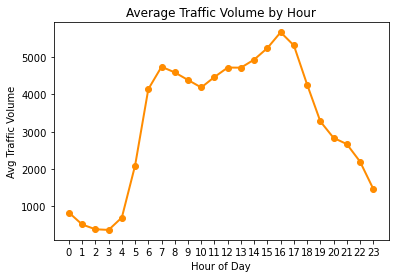

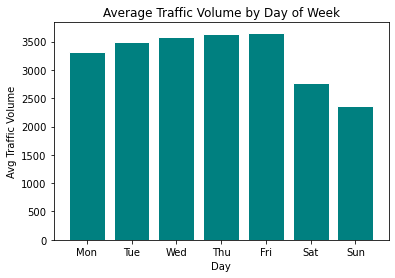

In [8]:
# Traffic volume by hour of day

hourly = df.groupby('hour')['traffic_volume'].mean()
plt.plot(hourly.index.to_numpy(), hourly.values, marker='o', color='darkorange', linewidth=2)
plt.title('Average Traffic Volume by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Traffic Volume')
plt.xticks(range(0, 24))
plt.show()

# Traffic volume by day of week
daily = df.groupby('day_of_week')['traffic_volume'].mean()
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
plt.bar(day_names, daily.values, color='teal', edgecolor='white')
plt.title('Average Traffic Volume by Day of Week')
plt.xlabel('Day')
plt.ylabel('Avg Traffic Volume')

plt.show()

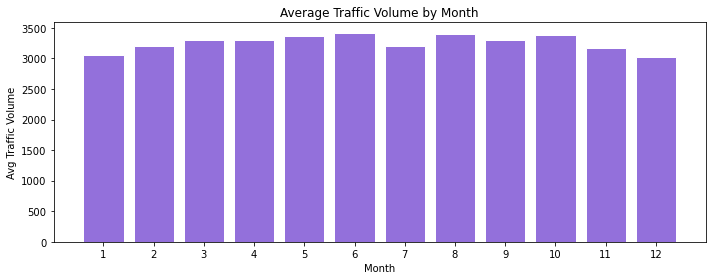

In [9]:
# Monthly trend
monthly = df.groupby('month')['traffic_volume'].mean()
plt.figure(figsize=(10, 4))
plt.bar(monthly.index.to_numpy(), monthly.values, color='mediumpurple', edgecolor='white')
plt.title('Average Traffic Volume by Month')
plt.xlabel('Month')
plt.ylabel('Avg Traffic Volume')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

### 3.3 Weather Features

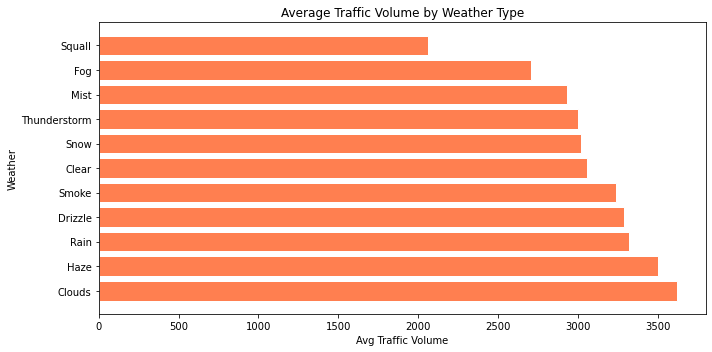

In [10]:
weather_traffic = df.groupby('weather_main')['traffic_volume'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(weather_traffic.index.to_numpy(), weather_traffic.values, color='coral', edgecolor='white')
plt.title('Average Traffic Volume by Weather Type')
plt.xlabel('Avg Traffic Volume')
plt.ylabel('Weather')
plt.tight_layout()
plt.show()

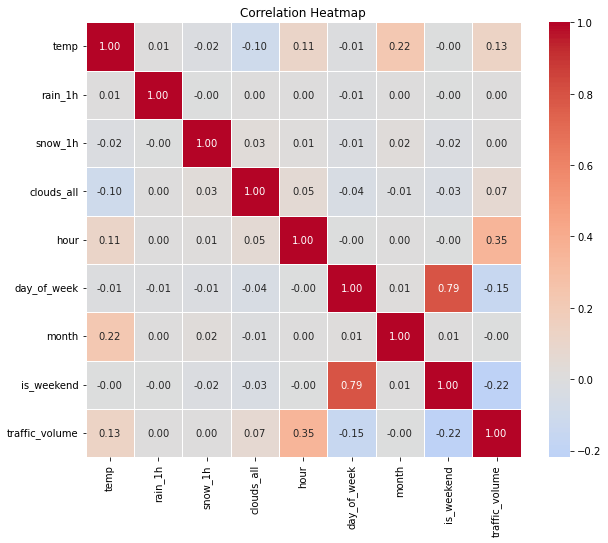

In [11]:
# Correlation heatmap (numeric features)
numeric_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'hour', 'day_of_week',
                'month', 'is_weekend', 'traffic_volume']

plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True,
            linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## 4. Data Preprocessing

In [12]:
# Drop duplicates
df.drop_duplicates(inplace=True)
print(f'Shape after dropping duplicates: {df.shape}')

# Create binary holiday feature (1 = holiday, 0 = not)
df['is_holiday'] = df['holiday'].notna().astype(int)
print(f"Holiday rows: {df['is_holiday'].sum()}")

# Encode weather_main using LabelEncoder
le_weather = LabelEncoder()
df['weather_main_enc'] = le_weather.fit_transform(df['weather_main'])
print(f'Weather categories encoded: {le_weather.classes_}')

# Handle temp = 0 (likely missing/erroneous — replace with median)
zero_temp = (df['temp'] == 0).sum()
print(f'\nRows with temp=0: {zero_temp}')
df.loc[df['temp'] == 0, 'temp'] = df['temp'].median()

Shape after dropping duplicates: (48187, 14)
Holiday rows: 61
Weather categories encoded: ['Clear' 'Clouds' 'Drizzle' 'Fog' 'Haze' 'Mist' 'Rain' 'Smoke' 'Snow'
 'Squall' 'Thunderstorm']

Rows with temp=0: 10


In [13]:
# Select features for modelling
feature_cols = ['temp', 'rain_1h', 'snow_1h', 'clouds_all',
                'weather_main_enc', 'hour', 'day_of_week', 'month',
                'is_weekend', 'is_holiday']

X = df[feature_cols]
y = df['traffic_volume']

print(f'Features shape: {X.shape}')
print(f'Target shape:   {y.shape}')
X.head()

Features shape: (48187, 10)
Target shape:   (48187,)


,temp,rain_1h,snow_1h,clouds_all,weather_main_enc,hour,day_of_week,month,is_weekend,is_holiday
0,288.28,0.0,0.0,40,1,9,1,10,0,0
1,289.36,0.0,0.0,75,1,10,1,10,0,0
2,289.58,0.0,0.0,90,1,11,1,10,0,0
3,290.13,0.0,0.0,90,1,12,1,10,0,0
4,291.14,0.0,0.0,75,1,13,1,10,0,0


In [14]:
# Train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')

Training set: (38549, 10)
Test set:     (9638, 10)


## 5. Model Training & Evaluation

In [15]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    
    print(f'{name} :-')    
    print(f'  MAE  : {mae:,.2f}')
    print(f'  MSE  : {mse:,.2f}')
    print(f'  RMSE : {rmse:,.2f}')
    print(f'  R²   : {r2:.4f}')

### 5.1 Random Forest Regressor

In [16]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

rf_results = evaluate_model('Random Forest', rf_model, X_train, X_test, y_train, y_test)

Random Forest :-
  MAE  : 245.57
  MSE  : 181,429.18
  RMSE : 425.95
  R²   : 0.9546


### 5.2 AdaBoost Regressor

In [17]:
ada_model = AdaBoostRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

ada_results = evaluate_model('AdaBoost', ada_model, X_train, X_test, y_train, y_test)

AdaBoost :-
  MAE  : 620.11
  MSE  : 697,733.98
  RMSE : 835.30
  R²   : 0.8255


### 5.3 XGBoost Regressor

In [18]:
xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_results = evaluate_model('XGBoost', xgb_model, X_train, X_test, y_train, y_test)

XGBoost :-
  MAE  : 238.80
  MSE  : 158,083.69
  RMSE : 397.60
  R²   : 0.9605


---
# Appendix — Detailed Concepts, Modules, Functions & Model Explanations

This section provides an in-depth explanation of every concept, library, function, and model used in this notebook.

### `sklearn` (scikit-learn)
Scikit-learn is the standard machine learning library in Python. It provides a consistent API for all models: `.fit(X, y)` to train, `.predict(X)` to predict.

**Modules and classes used from scikit-learn:**

| Import | Purpose |
|---|---|
| `sklearn.model_selection.train_test_split` | Splits data into training and testing sets randomly |
| `sklearn.preprocessing.LabelEncoder` | Encodes categorical string labels into integers (0, 1, 2, …) |
| `sklearn.metrics.mean_absolute_error` | Computes MAE |
| `sklearn.metrics.mean_squared_error` | Computes MSE |
| `sklearn.metrics.r2_score` | Computes R² (coefficient of determination) |
| `sklearn.ensemble.RandomForestRegressor` | Random Forest regression model |
| `sklearn.ensemble.AdaBoostRegressor` | AdaBoost regression model |

### `xgboost` (`XGBRegressor`)
XGBoost (eXtreme Gradient Boosting) is a highly optimised, distributed gradient boosting library. It wraps around scikit-learn's API so `.fit()` and `.predict()` work identically.

---
## A2. Key Concepts

### Supervised Learning (Regression)
All three models in this notebook perform **regression** — predicting a continuous numeric target (traffic volume) from input features.  
In supervised learning, the model learns a mapping **f: X → y** from labelled training data, where **X** is the feature matrix and **y** is the target vector.

### Train-Test Split
The dataset is divided into:
- **Training set (80%)** — used to train the model.
- **Test set (20%)** — held out and never seen during training; used to evaluate how well the model generalises.

`train_test_split(X, y, test_size=0.2, random_state=42)` performs this split.  
- `test_size=0.2` means 20% goes to testing.  
- `random_state=42` ensures the split is reproducible (same random seed each time).

### Feature Engineering
Raw data often needs to be transformed before modelling. In this notebook:
- **Temporal features** (`hour`, `day_of_week`, `month`, `year`, `is_weekend`) are extracted from the `date_time` column because decision trees cannot parse raw datetime strings.
- **`is_holiday`** is a binary feature (0 or 1) derived from the `holiday` column. If the `holiday` value is NaN (i.e., not a holiday), `is_holiday = 0`; otherwise `is_holiday = 1`.
- **Label Encoding** converts categorical weather strings (e.g., "Clouds", "Rain") into integers using `LabelEncoder`, since tree-based models require numeric input.
- **Data cleaning** — rows with `temp = 0` (likely sensor errors, since 0 Kelvin is physically impossible for surface temperature) are replaced with the median temperature.

### Ensemble Learning
An **ensemble method** combines multiple individual models (often called "weak learners" or "base estimators") to produce a single, stronger predictive model. The key insight is that a committee of models can outperform any single member.  
The three models in this notebook are all ensemble methods, but they differ in *how* they combine their base learners:
- **Bagging** (Bootstrap Aggregating) — Random Forest
- **Boosting** — AdaBoost, XGBoost

---
## A3. Evaluation Metrics Explained

### Mean Absolute Error (MAE)
$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$
- The average of the **absolute** differences between actual and predicted values.
- Easy to interpret: "On average, the prediction is off by MAE units."
- Treats all errors equally — no extra penalty for large errors.

### Mean Squared Error (MSE)
$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$
- The average of the **squared** differences.
- Penalises large errors disproportionately (due to squaring).
- Units are squared, so not directly interpretable in the original scale.

### Root Mean Squared Error (RMSE)
$$\text{RMSE} = \sqrt{\text{MSE}}$$
- The square root of MSE — brings the error back to the **original units** of the target.
- Still penalises large errors more than MAE.
- The most commonly reported regression error metric.

### R² Score (Coefficient of Determination)
$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$
- Measures the **proportion of variance** in the target that is explained by the model.
- Ranges from −∞ to 1. A value of 1 means perfect prediction; 0 means the model is no better than predicting the mean; negative values mean worse than the mean.
- A convenient, scale-free metric for comparing models.

---
## A4. Model 1 — Random Forest Regressor (In Detail)

### What is a Random Forest?
A Random Forest is an ensemble of **Decision Trees** trained using the **bagging** (Bootstrap Aggregating) technique. The final prediction is the **average** of all individual tree predictions (for regression).

### How Decision Trees Work
A Decision Tree recursively splits the data into subsets based on feature thresholds that minimise a loss function (e.g., MSE for regression).  
At each internal node, the tree asks a yes/no question like "Is `hour` ≤ 7?" and routes data left or right. The leaves hold the predicted value (mean of training samples that reached that leaf).

### How Random Forest Works — Step by Step
1. **Bootstrap Sampling**: For each of the `n_estimators` trees, draw a random sample **with replacement** from the training set. Each sample is typically the same size as the original data but will contain some duplicates and miss some rows (about 37% are left out — these are called **out-of-bag** samples).
2. **Random Feature Selection**: At each split in a tree, instead of considering **all** features, only a random subset of features is evaluated. This decorrelates the trees and increases diversity.
3. **Grow Full Trees**: Each tree is grown to a specified depth (or until leaves are pure / minimum sample size is reached). Individual trees may overfit, but that's okay because averaging corrects this.
4. **Aggregate**: For regression, the final prediction is the **mean** of all tree predictions. For classification, it would be a majority vote.

### Why It Works
- **Bias-Variance Trade-off**: Individual deep trees have **low bias** but **high variance** (they overfit). Averaging many such trees **reduces variance** without increasing bias, yielding a model with both low bias and low variance.
- The random feature selection ensures trees are sufficiently different from each other, which makes the averaging more effective.

### Hyperparameters Used
| Parameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 200 | Number of trees in the forest |
| `max_depth` | 15 | Maximum depth of each tree (limits overfitting) |
| `min_samples_split` | 5 | A node must have at least 5 samples to be split further |
| `random_state` | 42 | Seed for reproducibility |
| `n_jobs` | -1 | Use all CPU cores for parallel training |

### Strengths
- Handles non-linear relationships very well.
- Robust to outliers and noise.
- Provides feature importance scores.
- Training is embarrassingly parallel (each tree is independent).

### Weaknesses
- Memory-intensive for very large forests.
- Less interpretable than a single decision tree.
- Can be slow for prediction if there are many trees.

---
## A5. Model 2 — AdaBoost Regressor (In Detail)

### What is AdaBoost?
AdaBoost (Adaptive Boosting) is a **boosting** ensemble method. Unlike bagging (where trees are trained independently), boosting trains base learners **sequentially** — each new learner focuses on the errors made by the previous ones.

### How AdaBoost Regression Works — Step by Step
1. **Initialise**: Assign equal weight to every training sample: $w_i = \frac{1}{n}$.
2. **Train a Weak Learner**: Fit a simple base estimator (by default, a Decision Tree with `max_depth=3`, called a "decision stump" in classification, or a shallow tree in regression) on the **weighted** training data.
3. **Compute Error**: Calculate the weighted error of the learner. Samples that were predicted badly contribute more to the error.
4. **Compute Learner Weight**: A learner that performs better gets a **higher weight** ($\alpha$) in the final ensemble. The formula is based on the error rate: lower error → higher $\alpha$.
5. **Update Sample Weights**: **Increase** the weights of misclassified/poorly predicted samples so that the next learner pays more attention to them. **Decrease** the weights of correctly predicted samples.
6. **Repeat** steps 2–5 for `n_estimators` iterations.
7. **Final Prediction**: The weighted median (for regression) of all base learner predictions, where each learner's vote is weighted by its $\alpha$.

### Key Intuition
- Each successive learner is "adaptive" — it focuses on the **hard examples** that previous learners got wrong.
- The final model is a weighted combination of many weak learners, which together form a strong learner.

### Hyperparameters Used
| Parameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 200 | Number of sequential boosting rounds |
| `learning_rate` | 0.1 | Shrinks the contribution of each learner (lower = more regularisation, needs more estimators) |
| `random_state` | 42 | Seed for reproducibility |

### The `learning_rate` and `n_estimators` Trade-off
- A **lower learning rate** means each tree contributes less, so you need **more trees** (`n_estimators`) to achieve the same performance.
- A very high learning rate can cause overfitting; a very low one can cause underfitting if `n_estimators` is too small.
- Common practice: set `learning_rate` to 0.01–0.1 and increase `n_estimators` until validation performance plateaus.

### Why AdaBoost Performs Worse Here
- AdaBoost's default base learner is a **shallow decision tree** (`max_depth=3`), which is a very weak learner. For complex, non-linear data like traffic volume, these shallow trees cannot capture the rich interactions between features (e.g., hour × day_of_week).
- Unlike Random Forest and XGBoost which use deeper trees, AdaBoost's strength lies in scenarios where the relationship is simpler or when combined with more expressive base learners.
- AdaBoost is also more sensitive to **noisy data and outliers** because it aggressively up-weights misclassified samples.

### Strengths
- Simple and easy to implement.
- Less prone to overfitting than a single complex model (when properly tuned).
- Works well with a variety of base learners.

### Weaknesses
- Sensitive to noisy data and outliers (because it up-weights hard samples).
- Sequential training — cannot be parallelised.
- With default shallow base learners, struggles with complex non-linear patterns.

---
## A6. Model 3 — XGBoost Regressor (In Detail)

### What is XGBoost?
XGBoost (eXtreme Gradient Boosting) is an advanced, highly optimised implementation of **gradient boosted decision trees**. Like AdaBoost, it trains trees sequentially, but instead of re-weighting samples, it fits each new tree to the **residual errors** (gradients) of the previous ensemble.

### How Gradient Boosting Works — Step by Step
1. **Start with a Constant Prediction**: Initialise the model with a constant value (e.g., the mean of the target).
2. **Compute Residuals**: For each training sample, compute the **residual** = (actual value − current prediction). These residuals represent the errors the current model makes.
3. **Fit a Tree to the Residuals**: Train a new decision tree to predict the **residuals**, not the original target. This tree learns to correct the current model's errors.
4. **Update the Model**: Add the new tree's predictions (scaled by the `learning_rate`) to the current model:
   $$F_{m}(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$
   where $\eta$ is the learning rate and $h_m$ is the new tree.
5. **Repeat** steps 2–4 for `n_estimators` iterations.
6. **Final Prediction**: The sum of the initial constant plus all tree corrections.


### Hyperparameters Used
| Parameter | Value | Meaning |
|---|---|---|
| `n_estimators` | 200 | Number of boosting rounds (trees) |
| `max_depth` | 8 | Maximum depth of each tree |
| `learning_rate` | 0.1 | Step-size shrinkage — scales down each tree's contribution |
| `subsample` | 0.8 | Use 80% of training rows per tree (row subsampling) |
| `colsample_bytree` | 0.8 | Use 80% of features per tree (column subsampling) |
| `random_state` | 42 | Seed for reproducibility |
| `n_jobs` | -1 | Use all CPU cores |

### Why XGBoost Performs Best Here
- **Deeper trees** (`max_depth=8`) can capture complex non-linear interactions (e.g., rush-hour patterns differ on weekdays vs weekends).
- **Regularisation** and **subsampling** prevent the deep trees from overfitting.
- **Gradient-based optimisation** is more efficient than AdaBoost's re-weighting — it directly minimises the loss function.
- The combination of all these techniques makes XGBoost the most powerful general-purpose tabular data model.

### Strengths
- State-of-the-art performance on tabular/structured data.
- Built-in regularisation prevents overfitting.
- Handles missing values natively.
- Highly optimised — fast even on large datasets.
- Provides feature importance scores.

### Weaknesses
- Many hyperparameters to tune.
- Can overfit if hyperparameters are not properly set.
- Less interpretable than simpler models.
- Sequential nature (boosting) means training cannot be fully parallelised across trees.

---
## A7. Comparing the Three Models — Summary

| Aspect | Random Forest | AdaBoost | XGBoost |
|---|---|---|---|
| **Ensemble Strategy** | Bagging (parallel) | Boosting (sequential) | Gradient Boosting (sequential) |
| **Base Learner** | Deep decision trees | Shallow decision trees (stumps) | Moderate-depth decision trees |
| **How Trees are Combined** | Simple average | Weighted combination | Additive (sum of corrections) |
| **Error Handling** | Each tree sees a bootstrap sample | Each tree focuses on previously hard samples | Each tree fits the residual errors |
| **Regularisation** | Implicit (averaging) | None built-in | L1, L2, subsampling |
| **Parallelism** | Fully parallel (trees are independent) | Strictly sequential | Trees are sequential, but split-finding is parallel |
| **Overfitting Risk** | Moderate | Low (weak learners) but sensitive to noise | Moderate (controlled by regularisation) |
| **Noise Sensitivity** | Robust | Very sensitive | Moderate |
| **Typical Use Case** | General-purpose; works out-of-the-box | Simple datasets; quick baseline | Competitions; maximum accuracy on tabular data |

### When to Use Which?
- **Random Forest**: When you want a reliable, easy-to-tune model that works well out-of-the-box. Great first choice for any tabular regression or classification problem.
- **AdaBoost**: When your data is relatively clean (few outliers) and the underlying relationship is not too complex. Good for quick baselines or when combined with stronger base learners.
- **XGBoost**: When you need maximum predictive performance and are willing to invest time in hyperparameter tuning. The go-to model for Kaggle competitions and production ML systems on structured data.

---
### A8. Interpreting the Results
In this notebook, **`hour`** is consistently the most important feature across all three models, which makes physical sense — traffic volume follows strong diurnal (daily) patterns with peaks during morning and evening rush hours.

Other important features:
- **`temp`** — temperature correlates with season and outdoor activity patterns.
- **`day_of_week`** — weekday vs weekend traffic patterns differ significantly.
- **`month`** — seasonal variation in traffic.